# Where does sensorimotor integration happen?

In [29]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

import pyaldata as pyal
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import seaborn as sns
import cupy as cp

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import r2_score, make_scorer

from tqdm import tqdm

import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors

import pickle



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Maybe in DLS?

In [2]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_06_14_00',
    combine_time_bins=False
)
df_ = handler.df.copy()


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [3]:
ALL_BHV_FIELDS = [
    "left_ankle",
    # "left_ankle_angle",
    "left_elbow",
    # "left_elbow_angle",
    "left_foot",
    "left_knee",
    # "left_knee_angle",
    "left_paw",
    "left_shoulder",
    "left_wrist",
    # "left_wrist_angle",
    "right_ankle",
    # "right_ankle_angle",
    "right_elbow",
    # "right_elbow_angle",
    "right_foot",
    "right_knee",
    # "right_knee_angle",
    "right_paw",
    "right_shoulder",
    "right_wrist",
    # "right_wrist_angle",
    "shoulder_center",
    "tail_base",
    "tail_middle",
    "tail_tip",
]
FORE_KEYWORDS = [
    "wrist",
    "paw",
    "elbow",
]

HIND_KEYWORDS = [
    "foot",
    "ankle",
    "knee",
]


def get_limb(forelimb: bool, laterality: str):
    if forelimb:
        body_parts = FORE_KEYWORDS
    else:
        body_parts = HIND_KEYWORDS

    bhv_fields = [
        field
        for field in ALL_BHV_FIELDS
        if (laterality in field) and any(body_part in field for body_part in body_parts)
    ]
    return bhv_fields

bhv_combinations = {}
bhv_combinations["left_forelimb"] = get_limb(forelimb=True, laterality="left")
bhv_combinations["right_forelimb"] = get_limb(forelimb=True, laterality="right")
bhv_combinations["left_hindlimb"] = get_limb(forelimb=False, laterality="left")
bhv_combinations["right_hindlimb"] = get_limb(forelimb=False, laterality="right")

bhv_combinations["forelimbs"] = (
    bhv_combinations["left_forelimb"] + bhv_combinations["right_forelimb"]
)
bhv_combinations["hindlimbs"] = (
    bhv_combinations["left_hindlimb"] + bhv_combinations["right_hindlimb"]
)
bhv_combinations["tail"] = ["tail_base", "tail_middle", "tail_tip"]
bhv_combinations["all"] = ["all"]


In [34]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df, n_components=None, pca_fields='CP_rates')
# df = dt.add_bhv(df)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
# df = dt.balance_classes(df, 'values_Sol_direction')
df = dt.add_bhv(df, bhv_fields=bhv_combinations["left_hindlimb"])
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -100, rel_end= 150)


Dropped 11 of 333 rows (3.30%).


In [6]:
# Test if it works
model = decode.ReducedRankRegressorBence(rank=10, reg=0.05)
X = np.concatenate(df.CP_rates_pca.values)
y = np.concatenate(df.bhv.values)
scores = cross_val_score(
    model, 
    X, 
    y, 
    cv=KFold(5, shuffle=True),
    scoring=decode.get_custom_scorer()
)
print(f"Avg. score across folds: {scores.mean():.4f}")

Avg. score across folds: 0.1544


In [35]:
def get_cv_scoress_all_ranks(
    X, y, cv=KFold(5, shuffle=True), reg=None, step=5
):

    max_possible_rank = max(y.shape[1], X.shape[1])
    print(f"Max possible rank: {max_possible_rank}")
    rank_list = np.arange(1, max_possible_rank, step=step)

    cv_scores = []
    for rank in tqdm(rank_list):
        cv_scores.append(
            cross_val_score(
                decode.ReducedRankRegressorBence(rank, reg=reg),
                X,
                y,
                cv=cv,
                scoring=decode.get_custom_scorer(),
            )
        )
    cv_scores = np.stack(cv_scores)
    return rank_list, cv_scores

X = np.concatenate(perturb_td.CP_rates_pca.values)
y = np.concatenate(perturb_td.bhv.values)

rank_list, cv_scores_left_hindlimb = get_cv_scoress_all_ranks(X, y, step=1)

Max possible rank: 172


100%|██████████| 171/171 [01:28<00:00,  1.93it/s]


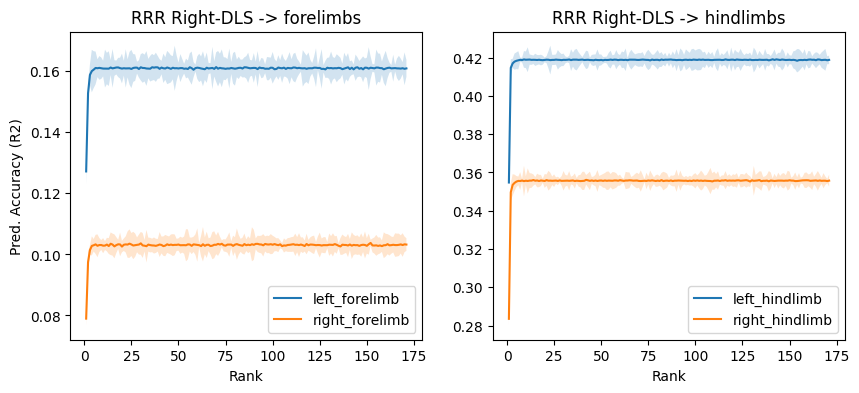

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex='all')
vizutils.shaded_errorbar(ax[0], rank_list, cv_scores_left_forelimb, label='left_forelimb')
vizutils.shaded_errorbar(ax[0], rank_list, cv_scores_right_forelimb, label='right_forelimb')

vizutils.shaded_errorbar(ax[1], rank_list, cv_scores_left_hindlimb, label='left_hindlimb')
vizutils.shaded_errorbar(ax[1], rank_list, cv_scores_right_hindlimb, label='right_hindlimb')

ax[0].set_title('RRR Right-DLS -> forelimbs')
ax[0].legend()
ax[1].set_title('RRR Right-DLS -> hindlimbs')
ax[1].legend()
ax[0].set_ylabel('Pred. Accuracy (R2)')
ax[0].set_xlabel('Rank')
ax[1].set_xlabel('Rank')
# ax[1].set_xlim(0, 20)


plt.show()

In [123]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df, n_components=None)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')

Dropped 11 of 333 rows (3.30%).


In [55]:
def get_cv_scoress_all_components(
    X, y, cv=KFold(5, shuffle=True), reg=None, step=5
):

    max_possible_comp = X.shape[1]
    print(f"Max possible components: {max_possible_comp}")
    comp_list = np.arange(1, max_possible_comp, step=step)

    cv_scores = []
    for comp in tqdm(comp_list):
        cv_scores.append(
            cross_val_score(
                decode.ReducedRankRegressorBence(max_possible_comp, reg=reg),
                X[:, :comp],
                y,
                cv=cv,
                scoring=decode.get_custom_scorer(),
            )
        )
    cv_scores = np.stack(cv_scores)
    return comp_list, cv_scores

cv_comps = {}
for body_part in ["left_forelimb", "left_hindlimb", "right_forelimb", "right_hindlimb"]:
    df__ = dt.add_bhv(df, bhv_fields=bhv_combinations[body_part])
    perturb_td = pyal.restrict_to_interval(df__, 'idx_sol_on', rel_start = -100, rel_end= 150)

    X = np.concatenate(perturb_td.CP_rates_pca.values)
    y = np.concatenate(perturb_td.bhv.values)

    comp_list, cv_comps[body_part]= get_cv_scoress_all_components(X, y, step=1)

Max possible components: 172


100%|██████████| 171/171 [00:50<00:00,  3.37it/s]


Max possible components: 172


100%|██████████| 171/171 [00:50<00:00,  3.37it/s]


Max possible components: 172


100%|██████████| 171/171 [00:50<00:00,  3.37it/s]


Max possible components: 172


100%|██████████| 171/171 [00:50<00:00,  3.36it/s]


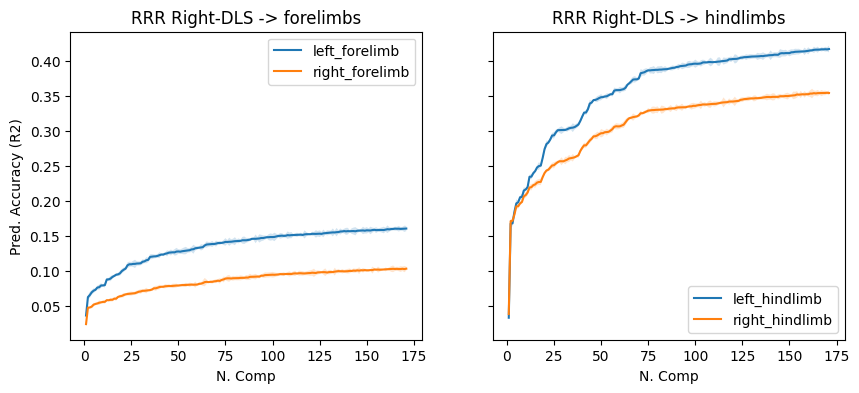

In [65]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex='all', sharey='all')
vizutils.shaded_errorbar(ax[0], comp_list, cv_comps["left_forelimb"], label='left_forelimb')
vizutils.shaded_errorbar(ax[0], comp_list, cv_comps["right_forelimb"], label='right_forelimb')

vizutils.shaded_errorbar(ax[1], comp_list, cv_comps["left_hindlimb"], label='left_hindlimb')
vizutils.shaded_errorbar(ax[1], comp_list, cv_comps["right_hindlimb"], label='right_hindlimb')

ax[0].set_title('RRR Right-DLS -> forelimbs')
ax[0].legend()
ax[1].set_title('RRR Right-DLS -> hindlimbs')
ax[1].legend()
ax[0].set_ylabel('Pred. Accuracy (R2)')
ax[0].set_xlabel('N. Comp')
ax[1].set_xlabel('N. Comp')
# ax[1].set_xlim(0, 20)


plt.show()

In [58]:
cv_comps_mop = {}
for body_part in ["left_forelimb", "left_hindlimb", "right_forelimb", "right_hindlimb"]:
    df__ = dt.add_bhv(df, bhv_fields=bhv_combinations[body_part])
    perturb_td = pyal.restrict_to_interval(df__, 'idx_sol_on', rel_start = -100, rel_end= 150)

    X = np.concatenate(perturb_td.MOp_rates_pca.values)
    y = np.concatenate(perturb_td.bhv.values)

    comp_list, cv_comps_mop[body_part]= get_cv_scoress_all_components(X, y, step=1)

Max possible components: 178


100%|██████████| 177/177 [00:55<00:00,  3.20it/s]


Max possible components: 178


100%|██████████| 177/177 [00:55<00:00,  3.18it/s]


Max possible components: 178


100%|██████████| 177/177 [00:55<00:00,  3.22it/s]


Max possible components: 178


100%|██████████| 177/177 [00:55<00:00,  3.18it/s]


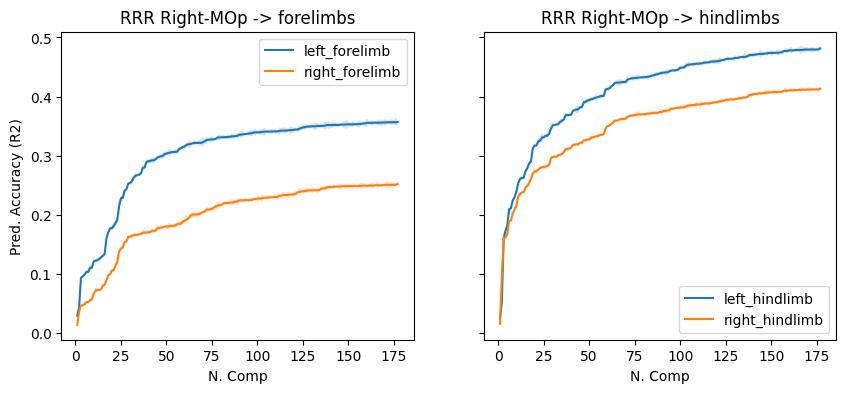

In [60]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex='all', sharey='all')
vizutils.shaded_errorbar(ax[0], comp_list, cv_comps_mop["left_forelimb"], label='left_forelimb')
vizutils.shaded_errorbar(ax[0], comp_list, cv_comps_mop["right_forelimb"], label='right_forelimb')

vizutils.shaded_errorbar(ax[1], comp_list, cv_comps_mop["left_hindlimb"], label='left_hindlimb')
vizutils.shaded_errorbar(ax[1], comp_list, cv_comps_mop["right_hindlimb"], label='right_hindlimb')

ax[0].set_title('RRR Right-MOp -> forelimbs')
ax[0].legend()
ax[1].set_title('RRR Right-MOp -> hindlimbs')
ax[1].legend()
ax[0].set_ylabel('Pred. Accuracy (R2)')
ax[0].set_xlabel('N. Comp')
ax[1].set_xlabel('N. Comp')
# ax[1].set_xlim(0, 20)


plt.show()

In [73]:
comp_list_mop, comp_list_cp = np.arange(1, 178), np.arange(1, 172)


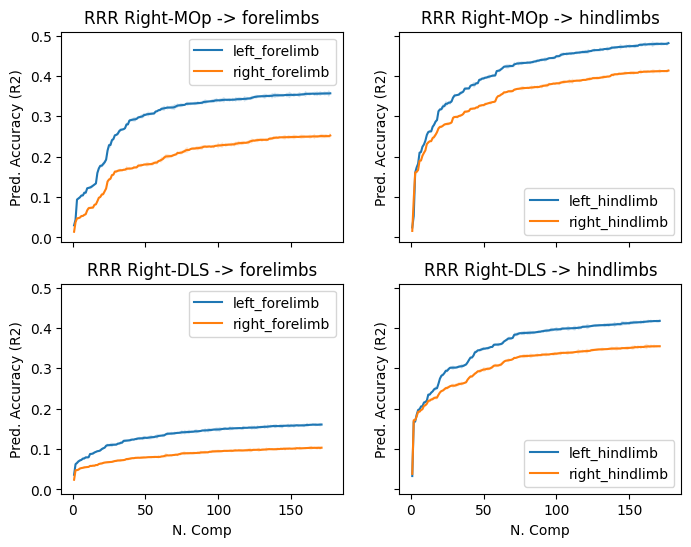

In [101]:
fig, axs = plt.subplots(2, 2, figsize=(8, 6), sharex='all', sharey='all')
axs = axs.flatten()
for ax, fore in zip(axs[:2], ['fore', 'hind']):
    vizutils.shaded_errorbar(ax, comp_list_mop, cv_comps_mop[f"left_{fore}limb"], label=f"left_{fore}limb")
    vizutils.shaded_errorbar(ax, comp_list_mop, cv_comps_mop[f"right_{fore}limb"], label=f"right_{fore}limb")
    ax.set_title(f'RRR Right-MOp -> {fore}limbs')
    ax.set_ylabel('Pred. Accuracy (R2)')
    ax.legend()

for ax, fore in zip(axs[2:], ['fore', 'hind']):
    vizutils.shaded_errorbar(ax, comp_list, cv_comps[f"left_{fore}limb"], label=f"left_{fore}limb")
    vizutils.shaded_errorbar(ax, comp_list, cv_comps[f"right_{fore}limb"], label=f"right_{fore}limb")
    ax.set_title(f'RRR Right-DLS -> {fore}limbs')

    ax.set_ylabel('Pred. Accuracy (R2)')
    ax.legend()
    ax.set_xlabel('N. Comp')



# ax[0].legend()
# ax[1].set_title('RRR Right-MOp -> hindlimbs')
# ax[1].legend()
# ax[0].set_xlabel('N. Comp')
# ax[1].set_xlabel('N. Comp')
# ax[1].set_xlim(0, 20)


plt.show()

## How does MOp predict DLS?

In [160]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df, n_components=None)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -100, rel_end= 150)

Dropped 11 of 333 rows (3.30%).


In [161]:
X = np.concatenate(perturb_td.MOp_rates_pca.values)
y = np.concatenate(perturb_td.CP_rates_pca.values)

rank_list, cv_scores_mop_dls = get_cv_scoress_all_ranks(X, y, step=5, cv=KFold(5, shuffle=False))

Max possible rank: 178


100%|██████████| 36/36 [00:33<00:00,  1.08it/s]


In [162]:
perturb_td.head()

,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,values_before_camera_trigger,...,GPe_rates,CP_rates,MOp_rates,sol_level_id,sol_contra_ipsi,SSp_rates_pca,VAL_rates_pca,GPe_rates_pca,CP_rates_pca,MOp_rates_pca
0,M061,M061_2025_03_06_14_00,362,trial,600,0.01,NaN,NaN,[],[],...,"[[33.043865, 8.714462, 39.19829, 8.835436, 0.0...","[[2.5908494, 52.45501, 24.812037, 19.728403, 5...","[[0.41590264, 7.428162, 0.0, 16.263794, 10.426...",0.0,1.0,"[[35.341667, -5.2573395, -22.729324, 10.11895,...","[[-25.079666, 32.7854, -12.578241, 2.1424255, ...","[[27.911499, 34.50815, 30.36084, -39.58062, 11...","[[-17.916824, 0.3288226, -8.99432, -4.0952682,...","[[-26.079391, -0.26727295, -9.544258, 7.934238..."
1,M061,M061_2025_03_06_14_00,278,trial,600,0.01,NaN,NaN,[],[],...,"[[36.272224, 22.210196, 40.69343, 15.754596, 0...","[[4.357046, 36.13122, 17.543253, 16.256767, 2....","[[0.0, 7.3918767, 0.0, 23.848278, 3.4276934, 0...",1.0,0.0,"[[43.931664, 12.338989, -25.177628, -9.611326,...","[[-11.35841, -0.917408, -35.79841, 12.795357, ...","[[26.160892, 8.89624, -24.63818, 26.79525, -31...","[[-27.475224, 1.1151538, -10.176842, -10.28398...","[[-18.373535, 8.893162, 1.9244375, 9.601856, -..."
2,M061,M061_2025_03_06_14_00,410,trial,600,0.01,NaN,NaN,[],[],...,"[[51.639717, 18.861393, 30.44932, 0.019238899,...","[[5.904538, 47.763004, 12.62192, 28.212696, 0....","[[0.0, 25.254036, 0.0, 39.12522, 1.8835385, 0....",0.0,1.0,"[[32.3291, 7.432617, -17.54789, -12.067068, 10...","[[-6.016775, 48.48452, 15.100374, 14.558128, 1...","[[21.50478, -3.2693024, 25.015038, 41.798016, ...","[[2.7939415, 4.988885, 48.37245, 43.796013, -0...","[[-10.833656, 32.957157, -5.841382, 23.022678,..."
3,M061,M061_2025_03_06_14_00,20,trial,600,0.01,NaN,NaN,[],[],...,"[[30.54065, 15.351261, 49.18524, 0.0, 0.0, 49....","[[18.378092, 52.27891, 14.117314, 19.913557, 0...","[[7.3958497, 0.0, 35.974606, 0.11905071, 0.208...",1.0,0.0,"[[-65.05404, 18.87262, 2.4947128, 16.639816, 1...","[[-22.30351, -28.51296, -24.130198, -23.992783...","[[-106.00157, 30.83194, 4.2491493, -8.469657, ...","[[-6.3049927, -32.107285, -8.015403, -10.91226...","[[-37.07766, -34.982624, 23.358334, -0.4217415..."
4,M061,M061_2025_03_06_14_00,222,trial,600,0.01,NaN,NaN,[],[],...,"[[27.25778, 24.49497, 45.42412, 12.428355, 0.0...","[[4.471336, 57.272114, 15.255565, 29.290209, 0...","[[0.0, 13.040992, 0.0, 34.937145, 7.0398474, 0...",1.0,0.0,"[[7.45912, 8.103798, 6.036972, -13.952095, 18....","[[3.7389374, -7.7232933, -2.7215023, 7.6336365...","[[-11.521816, 14.936539, -16.658848, 10.350724...","[[-4.849167, -1.1704302, -2.4043493, 9.988712,...","[[-4.7845535, 21.923252, 19.094872, -19.006933..."


(0.0, 40.0)

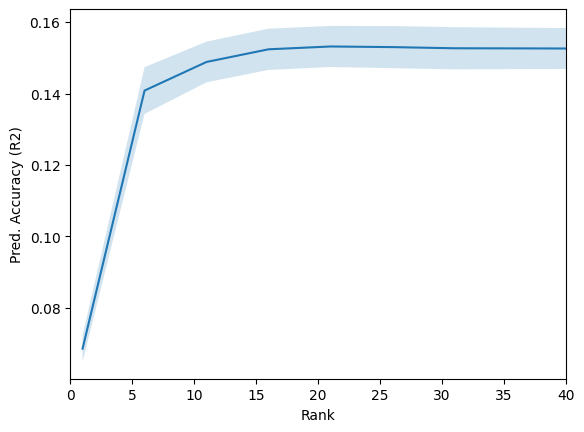

In [165]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, rank_list, cv_scores_mop_dls)
# vizutils.shaded_errorbar(ax, cv_scores_val_dls)

# ax.axhline(0.182)
ax.set_ylabel('Pred. Accuracy (R2)')
ax.set_xlabel('Rank')
ax.set_xlim(0, 40)

(0.19, 0.22)

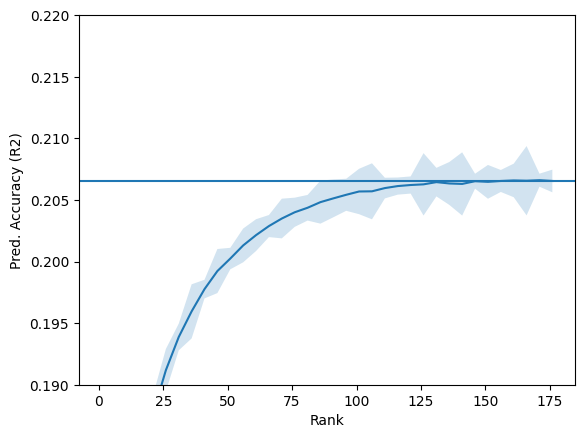

In [155]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, rank_list, cv_scores_mop_dls)
# vizutils.shaded_errorbar(ax, cv_scores_val_dls)

ax.axhline(0.2065)
ax.set_ylabel('Pred. Accuracy (R2)')
ax.set_xlabel('Rank')
ax.set_ylim(0.19, 0.22)

(0.0, 40.0)

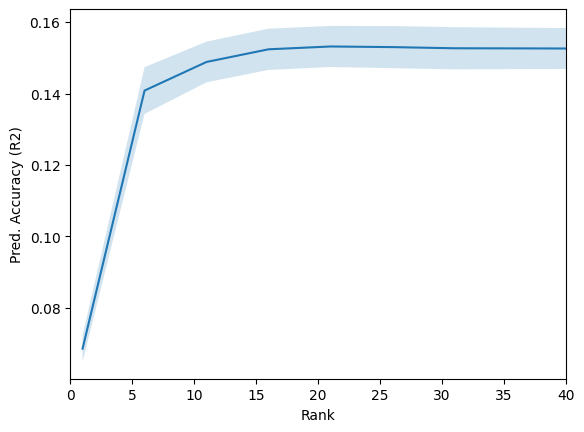

In [140]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, rank_list, cv_scores_mop_dls)
# vizutils.shaded_errorbar(ax, cv_scores_val_dls)

# ax.axhline(0.182)
ax.set_ylabel('Pred. Accuracy (R2)')
ax.set_xlabel('Rank')
ax.set_xlim(0, 40)

## How does VAL predict kinematics?

In [19]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df, n_components=None)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
df = dt.add_bhv(df, bhv_combinations['left_forelimb'])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -100, rel_end= 150)

Dropped 11 of 333 rows (3.30%).


In [20]:
X = np.concatenate(perturb_td.VAL_rates_pca.values)
y = np.concatenate(perturb_td.bhv.values)

model = decode.ReducedRankRegressorBenceGPU(
    rank=X.shape[1]
)
model.fit(X, y)
scores = cross_val_score(model, X, y, cv=KFold(n_splits=5, shuffle=False), scoring=decode.get_custom_scorer())
scores.mean()

0.12335041526229351

In [23]:
X = np.concatenate(perturb_td.MOp_rates_pca.values)
y = np.concatenate(perturb_td.bhv.values)

model = decode.ReducedRankRegressorBenceGPU(
    rank=X.shape[1]
)
model.fit(X, y)
scores = cross_val_score(model, X, y, cv=KFold(n_splits=5, shuffle=False), scoring=decode.get_custom_scorer())
scores.mean()

0.3344455339883208

In [ ]:
def get_cv_scoress_all_components_gpu(
    X, y, cv=KFold(5, shuffle=True), reg=None, step=5
):

    max_possible_comp = X.shape[1]
    print(f"Max possible components: {max_possible_comp}")
    comp_list = np.arange(1, max_possible_comp, step=step)

    cv_scores = []
    for comp in tqdm(comp_list):
        cv_scores.append(
            cross_val_score(
                decode.ReducedRankRegressorBenceGPU(max_possible_comp),
                X[:, :comp],
                y,
                cv=cv,
                scoring=decode.get_custom_scorer(),
            )
        )
    cv_scores = np.stack(cv_scores)
    mempool = cp.get_default_memory_pool()
    pinned_mempool = cp.get_default_pinned_memory_pool()

    # You can clear the memory pool by calling `free_all_blocks`.
    mempool.free_all_blocks()
    pinned_mempool.free_all_blocks()

    return comp_list, cv_scores

cv_comps_val = {}
X = np.concatenate(perturb_td.VAL_rates_pca.values)
y = np.concatenate(perturb_td.bhv.values)
comp_list, cv_comps_val['left_forelimb']= get_cv_scoress_all_components_gpu(X, y, step=1)

Max possible components: 168


100%|██████████| 167/167 [00:19<00:00,  8.75it/s]


Text(0.5, 0, 'Components')

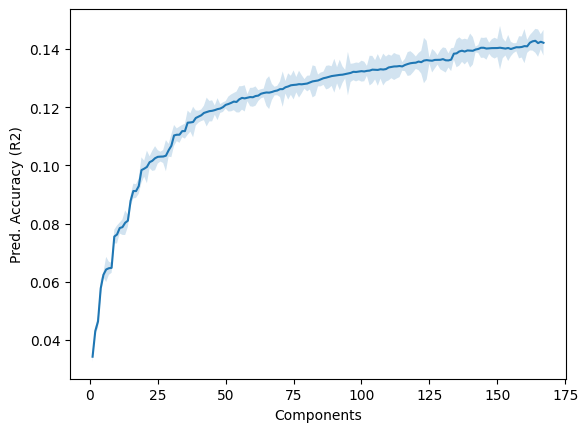

In [30]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, comp_list, cv_comps_val['left_forelimb'])
# vizutils.shaded_errorbar(ax, cv_scores_val_dls)

# ax.axhline(0.182)
ax.set_ylabel('Pred. Accuracy (R2)')
ax.set_xlabel('Components')
# ax.set_xlim(0, 40)

In [40]:
model.coef_.get().T[23, :]

array([ 0.01041704, -0.00790515,  0.0325482 ,  0.04418278,  0.00502589,
        0.06285166,  0.02769985,  0.00206755,  0.06775184])

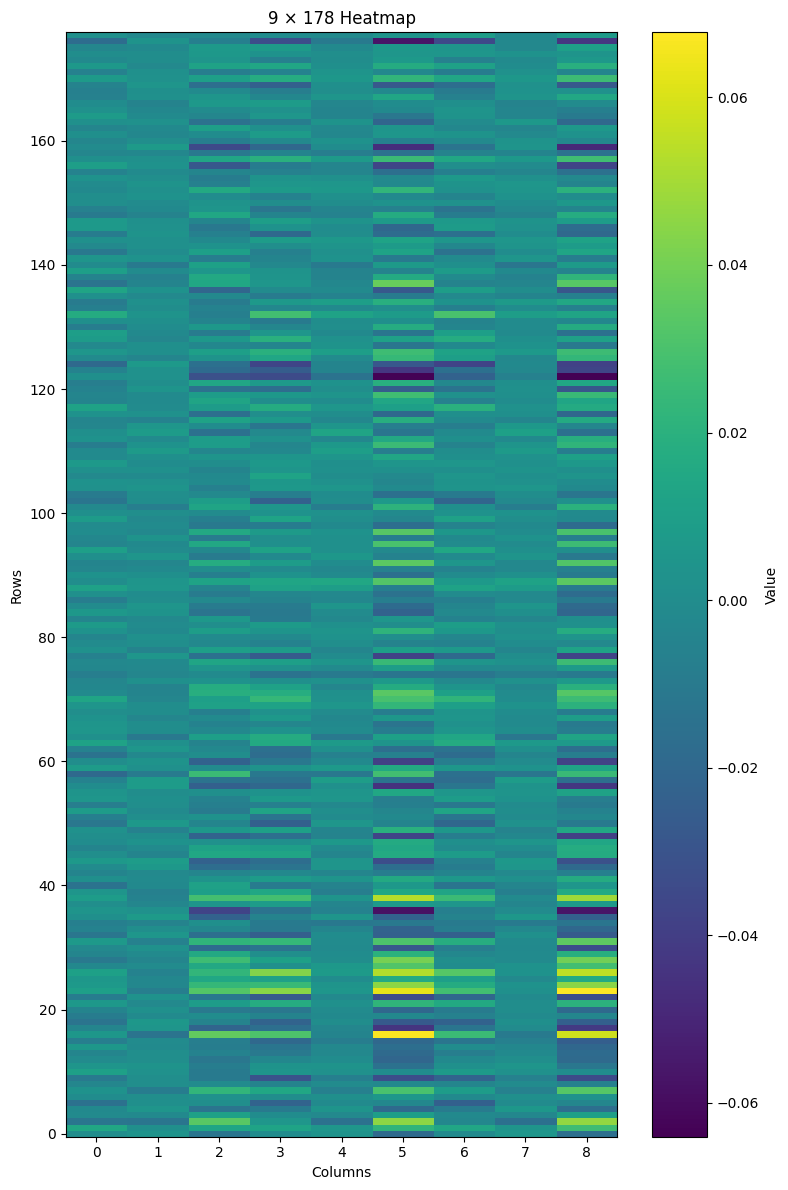

In [36]:
fig, ax = plt.subplots(figsize=(8, 12))

im = ax.imshow(model.coef_.get().T, aspect='auto', cmap='viridis', origin='lower')

# Add colorbar linked to this axis
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Value')

ax.set_xlabel('Columns')
ax.set_ylabel('Rows')
ax.set_title('9 × 178 Heatmap')

fig.tight_layout()
